AUTOMATA FINITO DETERMINISTA - HOLA MUNDO

> Agregar bloque entrecomillado




=== TABLA DE TRANSICIÓN (PANDAS) ===


,Estado Actual,Símbolo Leído,Estado Siguiente
0,q0,h,q1
1,q1,o,q2
2,q2,l,q3
3,q3,a,q4
4,q4,espacio,q5
5,q5,m,q6
6,q6,u,q7
7,q7,n,q8
8,q8,d,q9
9,q9,o,q10



=== DIAGRAMA DE TRANSICIÓN (GRAPHVIZ) ===


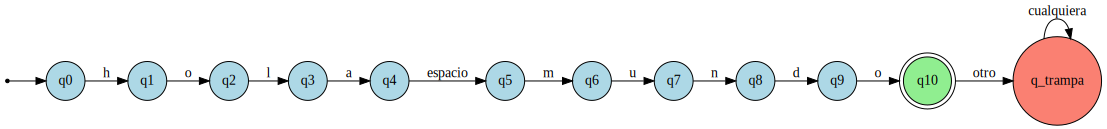


 SIMULADOR INTERACTIVO AFD: 'hola mundo'
Escribí 'salir' para detener el programa.


[*] Procesando: 'HOLA'
--------------------------------------------------
    Estado q0       --(lee 'H')--> Estado q_trampa
    [!] Secuencia rota. El autómata cayó en el estado trampa.
--------------------------------------------------
[X] Cadena RECHAZADA. Finalizó en un estado inválido: q_trampa



[*] Procesando: 'holla'
--------------------------------------------------
    Estado q0       --(lee 'h')--> Estado q1
    Estado q1       --(lee 'o')--> Estado q2
    Estado q2       --(lee 'l')--> Estado q3
    Estado q3       --(lee 'l')--> Estado q_trampa
    [!] Secuencia rota. El autómata cayó en el estado trampa.
--------------------------------------------------
[X] Cadena RECHAZADA. Finalizó en un estado inválido: q_trampa



[*] Procesando: 'holamundo'
--------------------------------------------------
    Estado q0       --(lee 'h')--> Estado q1
    Estado q1       --(lee 'o')--> Estado q2
 

KeyboardInterrupt: Interrupted by user

In [ ]:
# ==========================================
# INSTALACIÓN DE DEPENDENCIAS (Solo Colab)
# Descomentá estas 3 líneas si es un cuaderno nuevo:
# !apt-get -qq update > /dev/null
# !apt-get -qq install -y graphviz > /dev/null
# %pip -q install graphviz pandas
# ==========================================

import pandas as pd
from graphviz import Digraph
from IPython.display import display

class AFD_HolaMundo:
    def __init__(self):
        # 1. ESTADOS (Q) y CONFIGURACIÓN INICIAL
        self.Q = {
            'q0', 'q1', 'q2', 'q3', 'q4',
            'q5', 'q6', 'q7', 'q8', 'q9', 'q10', 'q_trampa'
        }
        self.q0 = 'q0'       # Estado inicial
        self.F = {'q10'}     # Conjunto de estados finales (aceptación)

        # 2. FUNCIÓN DE TRANSICIÓN (delta)
        # LÓGICA DETERMINISTA: Al ser un AFD, para un estado dado y un carácter específico,
        # existe exactamente UN ÚNICO camino a seguir. No hay bifurcaciones.
        self.delta = {
            'q0': {'h': 'q1'},
            'q1': {'o': 'q2'},
            'q2': {'l': 'q3'},
            'q3': {'a': 'q4'},
            'q4': {' ': 'q5'},   # El espacio cuenta como un carácter válido
            'q5': {'m': 'q6'},
            'q6': {'u': 'q7'},
            'q7': {'n': 'q8'},
            'q8': {'d': 'q9'},
            'q9': {'o': 'q10'},
            'q10': {},           # Estando en el final, cualquier letra extra rompe la secuencia
            'q_trampa': {}       # Del estado trampa no se sale nunca
        }

    # ==========================================
    # MÉTODOS VISUALES (PANDAS Y GRAPHVIZ)
    # ==========================================
    def mostrar_tabla(self):
        print("\n=== TABLA DE TRANSICIÓN (PANDAS) ===")
        # Armamos una lista de listas con el "camino correcto" y los errores
        filas = [
            ["q0", "h", "q1"], ["q1", "o", "q2"], ["q2", "l", "q3"],
            ["q3", "a", "q4"], ["q4", "espacio", "q5"], ["q5", "m", "q6"],
            ["q6", "u", "q7"], ["q7", "n", "q8"], ["q8", "d", "q9"],
            ["q9", "o", "q10"], ["q10", "otro", "q_trampa"], ["q_trampa", "cualquiera", "q_trampa"]
        ]
        # Generamos el DataFrame (Tabla) para que se vea prolijo
        df = pd.DataFrame(filas, columns=["Estado Actual", "Símbolo Leído", "Estado Siguiente"])
        display(df)

    def mostrar_diagrama(self):
        print("\n=== DIAGRAMA DE TRANSICIÓN (GRAPHVIZ) ===")
        dot = Digraph("AFD_HolaMundo", format="png")
        dot.attr(rankdir="LR") # Dibuja de izquierda a derecha

        # Pintamos los nodos según su rol
        for s in self.Q:
            if s in self.F:
                dot.node(s, shape="doublecircle", style="filled", fillcolor="lightgreen")
            elif s == 'q_trampa':
                dot.node(s, shape="circle", style="filled", fillcolor="salmon")
            else:
                dot.node(s, shape="circle", style="filled", fillcolor="lightblue")

        # Flecha de entrada al estado inicial
        dot.node("inicio", shape="point")
        dot.edge("inicio", self.q0)

        # Trazamos las líneas del diccionario delta
        for estado_origen, transiciones in self.delta.items():
            for simbolo, estado_destino in transiciones.items():
                etiqueta = "<espacio>" if simbolo == ' ' else simbolo
                dot.edge(estado_origen, estado_destino, label=etiqueta)

        # Agregamos las flechas que representan los errores explícitos para el gráfico
        dot.edge("q10", "q_trampa", label="otro")
        dot.edge("q_trampa", "q_trampa", label="cualquiera")

        display(dot)

    # ==========================================
    # LÓGICA DE PROCESAMIENTO LETRA POR LETRA
    # ==========================================
    def procesar_cadena(self, cadena):
        estado_actual = self.q0

        for simbolo in cadena:
            # EXPLICACIÓN LÓGICA DEL .get():
            # 1. Buscamos qué caminos salen del estado actual. Si no hay ninguno, devuelve vacío {}.
            diccionario_estado = self.delta.get(estado_actual, {})

            # 2. Buscamos a dónde lleva el símbolo ingresado.
            # Si el símbolo no está en el diccionario (es decir, leímos una letra incorrecta),
            # el segundo parámetro de .get() manda al autómata directo al 'q_trampa'.
            estado_siguiente = diccionario_estado.get(simbolo, 'q_trampa')

            # Mostramos el salto en pantalla para hacer la traza
            sim_print = "<espacio>" if simbolo == ' ' else simbolo
            print(f"    Estado {estado_actual:<8} --(lee '{sim_print}')--> Estado {estado_siguiente}")

            # Actualizamos el estado
            estado_actual = estado_siguiente

            # OPTIMIZACIÓN: Si ya caímos en la trampa, la cadena ya es inválida. Cortamos la lectura.
            if estado_actual == 'q_trampa':
                print("    [!] Secuencia rota. El autómata cayó en el estado trampa.")
                break

        # VERIFICACIÓN FINAL: ¿El estado en el que terminamos está dentro del conjunto de Finales (F)?
        es_aceptada = estado_actual in self.F

        print("-" * 50)
        if es_aceptada:
            print(f"[✓] Cadena ACEPTADA. Finalizó en el estado válido: {estado_actual}")
        else:
            print(f"[X] Cadena RECHAZADA. Finalizó en un estado inválido: {estado_actual}")

        return es_aceptada

# ==========================================
# BLOQUE DE EJECUCIÓN E INTERFAZ (Colab)
# ==========================================
if __name__ == "__main__":
    # 1. Creamos la instancia del autómata
    mi_afd = AFD_HolaMundo()

    # 2. Mostramos la teoría visual
    mi_afd.mostrar_tabla()
    mi_afd.mostrar_diagrama()

    # 3. Arrancamos el simulador interactivo
    print("\n" + "="*50)
    print(" SIMULADOR INTERACTIVO AFD: 'hola mundo'")
    print("="*50)
    print("Escribí 'salir' para detener el programa.\n")

    while True:
        cadena_usuario = input("Ingresá la palabra a validar: ")

        if cadena_usuario.lower() == 'salir':
            print("Cerrando simulador... ¡Éxitos en el TP!")
            break

        print(f"\n[*] Procesando: '{cadena_usuario}'")
        print("-" * 50)
        mi_afd.procesar_cadena(cadena_usuario)
        print("\n")

AUTOMATA FINITO DETERMINISTA - HOLA MUNDO



=== TABLA DE TRANSICIÓN AFND (PANDAS) ===


,Estado Actual,Símbolo,Estados Siguientes
0,p0,ε (épsilon),"{p1, p6}"
1,p1,h,{p2}
2,p2,o,{p3}
3,p3,l,{p4}
4,p4,a,{p5}
5,p6,m,{p7}
6,p7,u,{p8}
7,p8,n,{p9}
8,p9,d,{p10}
9,p10,o,{p11}



=== DIAGRAMA DE TRANSICIÓN AFND (GRAPHVIZ) ===


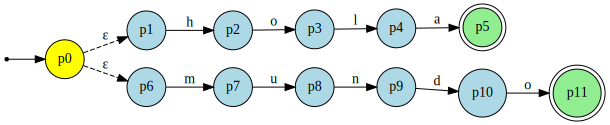


 PRUEBAS DE SIMULACIÓN

[*] Procesando: 'hola'
    Inicio. Estados vivos tras salto ε: {'p0', 'p6', 'p1'}
    --(lee 'h')--> Estados vivos: {'p2'}
    --(lee 'o')--> Estados vivos: {'p3'}
    --(lee 'l')--> Estados vivos: {'p4'}
    --(lee 'a')--> Estados vivos: {'p5'}
    [✓] ACEPTADA. Se alcanzó el final en: {'p5'}
------------------------------

[*] Procesando: 'mundo'
    Inicio. Estados vivos tras salto ε: {'p0', 'p6', 'p1'}
    --(lee 'm')--> Estados vivos: {'p7'}
    --(lee 'u')--> Estados vivos: {'p8'}
    --(lee 'n')--> Estados vivos: {'p9'}
    --(lee 'd')--> Estados vivos: {'p10'}
    --(lee 'o')--> Estados vivos: {'p11'}
    [✓] ACEPTADA. Se alcanzó el final en: {'p11'}
------------------------------

[*] Procesando: 'holamundo'
    Inicio. Estados vivos tras salto ε: {'p0', 'p6', 'p1'}
    --(lee 'h')--> Estados vivos: {'p2'}
    --(lee 'o')--> Estados vivos: {'p3'}
    --(lee 'l')--> Estados vivos: {'p4'}
    --(lee 'a')--> Estados vivos: {'p5'}
    --(lee 'm')--> Estado

In [ ]:
# ==========================================
# INSTALACIÓN DE DEPENDENCIAS (Solo Colab)
# Descomentá estas 3 líneas si es la primera vez que lo corrés:
# !apt-get -qq update > /dev/null
# !apt-get -qq install -y graphviz > /dev/null
# %pip -q install graphviz pandas
# ==========================================

import pandas as pd
from graphviz import Digraph
from IPython.display import display

class AFND_HolaMundo:
    def __init__(self):
        # 1. ESTADOS Y CONFIGURACIÓN INICIAL
        self.Q = {f'p{i}' for i in range(12)} # Genera p0 hasta p11
        self.q0 = 'p0'
        # Tenemos DOS estados finales porque hay dos palabras válidas
        self.F = {'p5', 'p11'}

        # 2. FUNCIÓN DE TRANSICIÓN (delta)
        # LÓGICA NO DETERMINISTA: Los destinos están dentro de LISTAS [].
        # Esto es porque desde un estado podríamos ir a varios destinos con la misma letra.
        self.delta = {
            # BIFURCACIÓN INICIAL: Transiciones vacías (épsilon)
            'p0': {'epsilon': ['p1', 'p6']},

            # --- RAMA 1: "hola" ---
            'p1': {'h': ['p2']},
            'p2': {'o': ['p3']},
            'p3': {'l': ['p4']},
            'p4': {'a': ['p5']},
            'p5': {}, # Fin de rama 1

            # --- RAMA 2: "mundo" ---
            'p6': {'m': ['p7']},
            'p7': {'u': ['p8']},
            'p8': {'n': ['p9']},
            'p9': {'d': ['p10']},
            'p10': {'o': ['p11']},
            'p11': {} # Fin de rama 2
        }

    # ==========================================
    # MÉTODOS VISUALES (PANDAS Y GRAPHVIZ)
    # ==========================================
    def mostrar_tabla(self):
        print("\n=== TABLA DE TRANSICIÓN AFND (PANDAS) ===")
        # En el AFND mostramos explícitamente los saltos vacíos
        filas = [
            ["p0", "ε (épsilon)", "{p1, p6}"],
            ["p1", "h", "{p2}"], ["p2", "o", "{p3}"], ["p3", "l", "{p4}"], ["p4", "a", "{p5}"],
            ["p6", "m", "{p7}"], ["p7", "u", "{p8}"], ["p8", "n", "{p9}"], ["p9", "d", "{p10}"], ["p10", "o", "{p11}"]
        ]
        df = pd.DataFrame(filas, columns=["Estado Actual", "Símbolo", "Estados Siguientes"])
        display(df)

    def mostrar_diagrama(self):
        print("\n=== DIAGRAMA DE TRANSICIÓN AFND (GRAPHVIZ) ===")
        dot = Digraph("AFND_HolaMundo", format="png")
        dot.attr(rankdir="LR")

        # Pintamos los nodos
        for s in sorted(list(self.Q), key=lambda x: int(x[1:])):
            if s in self.F:
                dot.node(s, shape="doublecircle", style="filled", fillcolor="lightgreen")
            elif s == 'p0':
                dot.node(s, shape="circle", style="filled", fillcolor="yellow") # Destacamos el inicio
            else:
                dot.node(s, shape="circle", style="filled", fillcolor="lightblue")

        dot.node("inicio", shape="point")
        dot.edge("inicio", self.q0)

        # Trazamos las conexiones leyendo el delta
        for estado_origen, transiciones in self.delta.items():
            for simbolo, destinos in transiciones.items():
                for estado_destino in destinos:
                    # Si el símbolo es epsilon, le ponemos la letra griega ε
                    etiq = "ε" if simbolo == 'epsilon' else simbolo
                    # Si es epsilon, hacemos la flecha punteada (estándar visual en autómatas)
                    estilo = "dashed" if simbolo == 'epsilon' else "solid"
                    dot.edge(estado_origen, estado_destino, label=etiq, style=estilo)

        display(dot)

    # ==========================================
    # LÓGICA CORE: CERRADURA ÉPSILON
    # ==========================================
    def _cerradura_epsilon(self, estados_actuales):
        """
        Calcula todos los estados a los que se puede llegar "gratis",
        es decir, sin consumir letras (viajando por flechas épsilon).
        """
        # Usamos un 'set' (conjunto) para que no haya estados duplicados
        estados_alcanzables = set(estados_actuales)
        pila = list(estados_actuales)

        while pila:
            estado = pila.pop()
            transiciones = self.delta.get(estado, {})

            if 'epsilon' in transiciones:
                for destino in transiciones['epsilon']:
                    if destino not in estados_alcanzables:
                        estados_alcanzables.add(destino)
                        pila.append(destino)

        return estados_alcanzables

    # ==========================================
    # LÓGICA DE PROCESAMIENTO (NO DETERMINISMO)
    # ==========================================
    def procesar_cadena(self, cadena):
        # 1. El autómata arranca y AUTOMÁTICAMENTE toma los caminos épsilon
        estados_activos = self._cerradura_epsilon({self.q0})

        print(f"\n[*] Procesando: '{cadena}'")
        print(f"    Inicio. Estados vivos tras salto ε: {estados_activos}")

        for simbolo in cadena:
            nuevos_estados = set()

            for estado in estados_activos:
                transiciones = self.delta.get(estado, {})

                if simbolo in transiciones:
                    for destino in transiciones[simbolo]:
                        nuevos_estados.add(destino)

            estados_activos = self._cerradura_epsilon(nuevos_estados)

            print(f"    --(lee '{simbolo}')--> Estados vivos: {estados_activos}")

            if not estados_activos:
                print("    [!] Todas las ramas murieron.")
                break

        es_aceptada = bool(estados_activos.intersection(self.F))

        if es_aceptada:
            estado_ganador = estados_activos.intersection(self.F)
            print(f"    [✓] ACEPTADA. Se alcanzó el final en: {estado_ganador}")
        else:
            print(f"    [X] RECHAZADA.")

        return es_aceptada

# ==========================================
# EJECUCIÓN DIRECTA (Sin Bucle Infinito)
# ==========================================
if __name__ == "__main__":
    afnd = AFND_HolaMundo()

    # 1. Mostramos la parte gráfica
    afnd.mostrar_tabla()
    afnd.mostrar_diagrama()

    # 2. Hacemos las pruebas directamente
    print("\n" + "="*50)
    print(" PRUEBAS DE SIMULACIÓN")
    print("="*50)

    # Prueba 1: Cadena válida (Rama 1)
    afnd.procesar_cadena("hola")
    print("-" * 30)

    # Prueba 2: Cadena válida (Rama 2)
    afnd.procesar_cadena("mundo")
    print("-" * 30)

    # Prueba 3: Cadena inválida
    afnd.procesar_cadena("holamundo")

AUTOMATA DE PILA - ANBN


In [ ]:
"""
AUTÓMATA DE PILA (PDA - Pushdown Automaton) - Implementación Educacional
=========================================================================

¿Qué es un Autómata de Pila?
------------------------------
Un Autómata de Pila es como un AFD pero con una PILA (stack) auxiliar.
Esa pila le da memoria ILIMITADA, permitiéndole reconocer lenguajes
que un AFD NUNCA podría procesar.

Definición formal:  M = (Q, Σ, Γ, δ, q0, Z0, F)
  ─────────────────────────────────────────────
  Q   : Conjunto finito de estados
  Σ   : Alfabeto de entrada  (símbolos que lee de la cinta)
  Γ   : Alfabeto de pila     (símbolos que puede apilar/desapilar)
  δ   : Función de transición
  q0  : Estado inicial
  Z0  : Símbolo de fondo de pila (marca el inicio de la pila)
  F   : Conjunto de estados de aceptación

La función de transición δ:
  δ(estado_actual, símbolo_leído, tope_de_pila) → (nuevo_estado, lo_que_se_apila)

  Siempre se hace POP del tope, luego PUSH de "lo_que_se_apila".
  Si "lo_que_se_apila" es [] → solo hubo POP (no se apila nada nuevo).
  La cadena 'ε' en el símbolo_leído → transición épsilon (sin consumir entrada).

════════════════════════════════════════════════════════════════════════════
  EJEMPLO: Lenguaje L = { a^n b^n | n ≥ 1 }
════════════════════════════════════════════════════════════════════════════
  Cadenas VÁLIDAS  :  ab   aabb   aaabbb   aaaabbbb
  Cadenas INVÁLIDAS:  a    b      ba       aab     abb

  Un AFD NO puede reconocer este lenguaje porque necesita recordar cuántas
  'a' leyó, sin ningún límite superior. La PILA resuelve esto:

    Estrategia:
      1. Por cada 'a' leída  →  hacer PUSH de 'A' en la pila
      2. Por cada 'b' leída  →  hacer POP  de 'A' de la pila
      3. Al terminar la cadena: si la pila solo tiene el fondo 'Z' → ACEPTAR

  Estados:
    q0  →  Estado inicial / leyendo las 'a'
    q1  →  Empezamos a leer las 'b' (ya no podemos leer más 'a')
    q2  →  Estado de aceptación (pila vaciada correctamente)

  Transiciones:
    δ(q0, 'a', 'Z') = (q0, ['Z','A'])   ←  primer  'a': reponemos Z, apilamos A (tope=A)
    δ(q0, 'a', 'A') = (q0, ['A','A'])   ←  demás   'a': reponemos A, apilamos otro A
    δ(q0, 'b', 'A') = (q1, [])          ←  primera 'b': desapilamos A
    δ(q1, 'b', 'A') = (q1, [])          ←  demás   'b': seguimos desapilando
    δ(q1, 'ε', 'Z') = (q2, ['Z'])       ←  pila vacía (solo Z): ACEPTAR

  push_list usa el convenio: el ÚLTIMO elemento queda en el tope.
    ['Z', 'A'] → pila crece como [..., Z, A]  donde tope es A.
"""

try:
    import networkx as nx
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    HAS_LIBS = True
except ImportError:
    HAS_LIBS = False
    print("=" * 60)
    print("ATENCIÓN: 'networkx' y 'matplotlib' no están instaladas.")
    print("El programa correrá en modo texto.")
    print("Para ver el gráfico: pip install networkx matplotlib")
    print("=" * 60 + "\n")


# ─────────────────────────────────────────────────────────────
#  Símbolo especial para epsilon (transición sin leer entrada)
# ─────────────────────────────────────────────────────────────
EPSILON = 'ε'
FONDO   = 'Z'   # Símbolo que marca el fondo de la pila


class AutomataDePila:
    """
    Autómata de Pila determinista que reconoce L = { a^n b^n | n >= 1 }.

    La pila se representa como una lista de Python donde:
      - pila[-1]  es el TOPE  (el elemento más reciente)
      - pila[0]   es el FONDO (símbolo 'Z', siempre el último)
    """

    def __init__(self):
        # ── Componentes formales ──────────────────────────────────────────
        self.Q  = ['q0', 'q1', 'q2']           # Estados (lista para orden determinista)
        self.sigma = {'a', 'b'}                 # Alfabeto de entrada
        self.gamma = {'A', FONDO}               # Alfabeto de pila
        self.q0 = 'q0'                          # Estado inicial
        self.Z0 = FONDO                         # Fondo de pila
        self.F  = {'q2'}                        # Estados de aceptación

        # ── Función de transición ─────────────────────────────────────────
        # Formato: delta[(estado, símbolo_entrada, tope_pila)] = (sig_estado, lo_que_se_apila)
        # "lo_que_se_apila" es una lista donde el ÚLTIMO elemento queda en el tope.
        # Ejemplo: ['Z','A'] → se apila primero Z (fondo) luego A → tope es A.
        self.delta = {
            ('q0', 'a', FONDO): ('q0', [FONDO, 'A']),   # primer 'a': tope→A
            ('q0', 'a', 'A'):   ('q0', ['A', 'A']),     # más 'a': tope→A
            ('q0', 'b', 'A'):   ('q1', []),              # primera 'b': pop A
            ('q1', 'b', 'A'):   ('q1', []),              # más 'b': pop A
            ('q1', EPSILON, FONDO): ('q2', [FONDO]),     # pila vacía → aceptar
        }

        # ── Posiciones para el grafo visual ──────────────────────────────
        if HAS_LIBS:
            self.pos = {
                'q0': (0, 0),
                'q1': (3, 0),
                'q2': (6, 0),
            }

    # ──────────────────────────────────────────────────────────────────────
    #  Método auxiliar: intentar transición épsilon si corresponde
    # ──────────────────────────────────────────────────────────────────────
    def _transicion_epsilon(self, estado, pila):
        """Retorna (nuevo_estado, nueva_pila) si hay transición ε, o None."""
        if not pila:
            return None
        tope = pila[-1]
        clave = (estado, EPSILON, tope)
        if clave in self.delta:
            sig_estado, push_list = self.delta[clave]
            nueva_pila = pila[:-1] + push_list  # pop tope, push lo nuevo
            return sig_estado, nueva_pila
        return None

    # ──────────────────────────────────────────────────────────────────────
    #  Visualización con matplotlib
    # ──────────────────────────────────────────────────────────────────────
    def _dibujar(self, estado_actual, pila, paso, simbolo_leido=None, entrada_restante=""):
        if not HAS_LIBS:
            return

        fig = plt.gcf()
        fig.clf()

        # Dos paneles: izquierda = grafo de estados, derecha = pila
        ax_grafo = fig.add_axes([0.03, 0.1, 0.62, 0.80])   # [left, bot, w, h]
        ax_pila  = fig.add_axes([0.70, 0.1, 0.26, 0.80])

        # ── Panel izquierdo: grafo de estados ────────────────────────────
        G = nx.DiGraph()
        for s in self.Q:
            G.add_node(s)

        # Etiquetas de aristas (resumimos las transiciones del delta)
        edges_labels = {}
        for (est, sym, tope), (sig_est, push) in self.delta.items():
            push_str = ''.join(push) if push else 'ε'
            label = f"{sym}/{tope}→{push_str}"
            key = (est, sig_est)
            existing = edges_labels.get(key, [])
            existing.append(label)
            edges_labels[key] = existing
            G.add_edge(est, sig_est)

        # Colores de nodos
        color_map = []
        for s in self.Q:
            if s == estado_actual:
                if s in self.F:
                    color_map.append('#00DD44')   # verde → aceptación activa
                else:
                    color_map.append('#FFDD00')   # amarillo → estado activo
            else:
                if s in self.F:
                    color_map.append('#AAFFCC')   # verde pálido
                else:
                    color_map.append('#ADD8E6')   # azul claro

        nx.draw_networkx_nodes(G, self.pos, ax=ax_grafo,
                               node_color=color_map, node_size=1800, edgecolors='black')
        nx.draw_networkx_labels(G, self.pos, ax=ax_grafo,
                                font_size=11, font_weight='bold')

        # Aristas — separamos self-loops de aristas normales
        regular_edges = [(u, v) for u, v in G.edges() if u != v]
        self_loops = [(u, v) for u, v in G.edges() if u == v]
        nx.draw_networkx_edges(G, self.pos, edgelist=regular_edges, ax=ax_grafo,
                               arrowsize=20, node_size=1800,
                               connectionstyle='arc3,rad=0.1')
        nx.draw_networkx_edges(G, self.pos, edgelist=self_loops, ax=ax_grafo,
                               arrowsize=15, node_size=1800,
                               connectionstyle='arc3,rad=0.4')

        # Etiquetas de aristas
        for (u, v), labels in edges_labels.items():
            x1, y1 = self.pos[u]
            x2, y2 = self.pos[v]
            if u == v:
                # Self-loop: etiqueta arriba del nodo
                mx, my = x1, y1 + 0.85
            else:
                mx, my = (x1 + x2) / 2, (y1 + y2) / 2 + 0.25
            ax_grafo.text(mx, my, '\n'.join(labels),
                          fontsize=7, ha='center', va='center',
                          color='darkred',
                          bbox=dict(boxstyle='round,pad=0.2', fc='lightyellow', alpha=0.8))

        # Marcar estado inicial con flecha
        xi, yi = self.pos[self.q0]
        ax_grafo.annotate('', xy=(xi, yi),
                          xytext=(xi - 1.0, yi),
                          arrowprops=dict(arrowstyle='->', color='black', lw=2))

        # Marcar estados de aceptación con doble círculo
        for s in self.F:
            xf, yf = self.pos[s]
            circle = plt.Circle((xf, yf), 0.28, fill=False,
                                 edgecolor='black', linewidth=2)
            ax_grafo.add_patch(circle)

        ax_grafo.set_xlim(-1.5, 7.5)
        ax_grafo.set_ylim(-1.5, 1.5)
        ax_grafo.axis('off')

        # Subtítulo del grafo
        titulo = f"Paso {paso}"
        if simbolo_leido is not None:
            titulo += f"  |  Leyó: '{simbolo_leido}'"
        titulo += f"  |  Estado: {estado_actual}"
        if entrada_restante:
            titulo += f"\nEntrada restante: '{entrada_restante}'"
        ax_grafo.set_title(titulo, fontsize=10, pad=6)

        # ── Panel derecho: visualización de la PILA ──────────────────────
        ax_pila.set_xlim(0, 2)
        ax_pila.set_ylim(-0.5, 10)
        ax_pila.axis('off')
        ax_pila.set_title("PILA (stack)", fontsize=11, fontweight='bold', pad=6)

        if not pila:
            ax_pila.text(1, 4, "(vacía)", ha='center', va='center',
                         fontsize=10, color='gray')
        else:
            # Dibujar cada elemento de la pila (el tope arriba)
            altura_base = 0.4
            max_visible = 8
            inicio = max(0, len(pila) - max_visible)
            segmento = pila[inicio:]

            for i, elem in enumerate(segmento):
                y = altura_base + i * 1.0
                es_tope = (i == len(segmento) - 1)
                color_caja = '#FF9966' if es_tope else '#FFE0CC'
                rect = mpatches.FancyBboxPatch(
                    (0.3, y), 1.4, 0.75,
                    boxstyle="round,pad=0.05",
                    linewidth=1.5,
                    edgecolor='#884400',
                    facecolor=color_caja
                )
                ax_pila.add_patch(rect)
                ax_pila.text(1.0, y + 0.375, elem,
                             ha='center', va='center',
                             fontsize=14, fontweight='bold')
                if es_tope:
                    ax_pila.text(1.85, y + 0.375, '← tope',
                                 ha='left', va='center', fontsize=7, color='gray')

            # Flecha "base de la pila" debajo del primer elemento
            ax_pila.text(1.0, altura_base - 0.35, '▼ fondo',
                         ha='center', va='top', fontsize=8, color='gray')

        plt.draw()
        plt.pause(1.2)

    # ──────────────────────────────────────────────────────────────────────
    #  Método principal: procesar una cadena de entrada
    # ──────────────────────────────────────────────────────────────────────
    def procesar(self, cadena):
        """
        Simula el autómata de pila sobre la cadena dada.
        Muestra cada paso en consola (y opcionalmente en gráfico).
        """
        estado  = self.q0
        pila    = [self.Z0]   # Pila inicial: solo el fondo Z
        paso    = 0

        print(f"\n{'─'*60}")
        print(f"  Procesando: '{cadena}'")
        print(f"{'─'*60}")
        print(f"  Estado inicial : {estado}")
        print(f"  Pila inicial   : {self._repr_pila(pila)}")
        print(f"{'─'*60}")

        self._dibujar(estado, pila, paso, entrada_restante=cadena)

        for i, simbolo in enumerate(cadena):
            tope = pila[-1] if pila else None
            clave = (estado, simbolo, tope)

            if clave not in self.delta:
                # Intentar transición ε antes de rechazar
                resultado_eps = self._transicion_epsilon(estado, pila)
                if resultado_eps:
                    estado, pila = resultado_eps
                    paso += 1
                    print(f"  Paso {paso}: δ({estado}, ε, '{tope}') "
                          f"→ transición ε  |  Pila: {self._repr_pila(pila)}")
                    self._dibujar(estado, pila, paso, EPSILON, cadena[i:])
                    # Re-intentar con el nuevo estado
                    tope = pila[-1] if pila else None
                    clave = (estado, simbolo, tope)

                if clave not in self.delta:
                    paso += 1
                    print(f"  Paso {paso}: '{simbolo}' con tope '{tope}' en {estado} → SIN TRANSICIÓN")
                    self._dibujar(estado, pila, paso, simbolo, cadena[i+1:])
                    print(f"\n  [RECHAZADA] No existe transición válida.\n")
                    return False

            sig_estado, push_list = self.delta[clave]
            pila = pila[:-1] + push_list   # pop tope + push lo nuevo

            paso += 1
            push_str = ''.join(push_list) if push_list else 'ε (solo pop)'
            print(f"  Paso {paso}: δ({estado}, '{simbolo}', '{tope}') "
                  f"→ ({sig_estado}, [{push_str}])  |  Pila: {self._repr_pila(pila)}")

            estado = sig_estado
            self._dibujar(estado, pila, paso, simbolo, cadena[i+1:])

        # ── Intentar transición épsilon al final ─────────────────────────
        resultado_eps = self._transicion_epsilon(estado, pila)
        if resultado_eps:
            tope_antes = pila[-1]
            sig_estado, nueva_pila = resultado_eps
            paso += 1
            print(f"  Paso {paso}: δ({estado}, ε, '{tope_antes}') "
                  f"→ ({sig_estado})  [transición ε]"
                  f"  |  Pila: {self._repr_pila(nueva_pila)}")
            estado, pila = sig_estado, nueva_pila
            self._dibujar(estado, pila, paso, EPSILON, "")

        # ── Decisión de aceptación / rechazo ─────────────────────────────
        aceptada = estado in self.F
        print(f"{'─'*60}")
        if aceptada:
            print(f"  [ACEPTADA]  Estado final: {estado}  |  Pila: {self._repr_pila(pila)}")
        else:
            print(f"  [RECHAZADA] Estado final: {estado}  |  Pila: {self._repr_pila(pila)}")
            if pila != [FONDO]:
                print(f"             La pila no quedó solo con el fondo {FONDO}.")
        print(f"{'─'*60}\n")
        return aceptada

    def _repr_pila(self, pila):
        """Muestra la pila de forma legible: [fondo → ... → tope]."""
        if not pila:
            return "[ vacía ]"
        return "[" + " → ".join(pila) + "]  ← tope: " + pila[-1]


# ──────────────────────────────────────────────────────────────────────────
#  Punto de entrada
# ──────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    if HAS_LIBS:
        plt.ion()
        fig = plt.figure("Autómata de Pila: aⁿbⁿ", figsize=(12, 5))

    pda = AutomataDePila()

    print("=" * 60)
    print("  SIMULADOR DE AUTÓMATA DE PILA")
    print("  Lenguaje: L = { aⁿbⁿ | n ≥ 1 }")
    print("  Ejemplos válidos:   ab  aabb  aaabbb")
    print("  Ejemplos inválidos: a   b   ba   aab")
    print("=" * 60)
    print("\n  Teoría rápida:")
    print("  ┌─────────────────────────────────────────────┐")
    print("  │  δ(estado, entrada, tope) → (nuevo, push)   │")
    print("  │  'push' vacío  = solo se hizo POP del tope  │")
    print("  └─────────────────────────────────────────────┘")
    print("\n  Escribí 'teoria' para ver las transiciones.")
    print("  Escribí 'salir'  para terminar.\n")

    while True:
        try:
            entrada = input("  Ingresá la cadena: ").strip()
        except (KeyboardInterrupt, EOFError):
            print("\n  Cerrando...\n")
            break

        if entrada.lower() == 'salir':
            print("  ¡Nos vemos!\n")
            break
        elif entrada.lower() == 'teoria':
            print("\n  Transiciones del autómata:")
            print("  ─────────────────────────────────────────────────")
            for (est, sym, tope), (sig, push) in sorted(pda.delta.items()):
                push_str = ''.join(push) if push else 'ε'
                print(f"  δ({est}, {sym}, {tope}) → ({sig}, [{push_str}])")
            print("  ─────────────────────────────────────────────────\n")
        else:
            pda.procesar(entrada)